# AnnData Annotations

This notebook merges cell annotations from the following sources:
* Seurat label transfer
* Manual annotations for dual-positive cells
* Neuronal class assignment based on labels

**Pinned Environment:** [`envs/sc-scvi.yaml`](../.../envs/sc-scvi.yaml)  

In [1]:
from pathlib import Path
import os
import scanpy as sc
import pandas as pd
import numpy as np
import anndata as ad
import warnings
import matplotlib.pyplot as plt

import session_info
import sys

In [2]:
sys.path.append(str(Path.cwd().resolve().parents[1]))

from config.paths import BASE_DIR, METADATA_DIR

# Data directories
input_dir = BASE_DIR / "data/h5ad/export_03/03a_scanvi"
adata_path = input_dir / "adata-scanvi-labels.h5ad"
seurat_labels_path = BASE_DIR / "data/rds/seurat/label_transfer_xenium.csv"

# Metadata inside Git repo
manual_annotations_path = METADATA_DIR / "manual-annotations.csv"

output_dir = BASE_DIR / "data/h5ad/export_03/03b_seurat"

In [3]:
adata = sc.read_h5ad(adata_path)
seurat_df = pd.read_csv(seurat_labels_path)
manual_df = pd.read_csv(manual_annotations_path)

# Seurat label transfer annotations

In [4]:
# Make a copy and set cell barcodes as index
labels = seurat_df.copy()
labels.index = labels["Unnamed: 0"]
labels = labels.drop(columns=["Unnamed: 0"])

# Keep rows present in adata, reindex
shared = labels.index.intersection(adata.obs_names)
labels = labels.loc[shared]
labels = labels.reindex(adata.obs_names)

# Add columns to adata
adata.obs = adata.obs.join(labels)

In [5]:
adata.obs

,cell_id,x_centroid,y_centroid,transcript_counts,control_probe_counts,genomic_control_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,...,prediction.score.Vascular_endothelial_1,prediction.score.Vascular_endothelial_2,prediction.score.Macrophage_1,prediction.score.Cycling.SGC,prediction.score.Pericyte,prediction.score.Macrophage_2,prediction.score.Fibroblast_2,prediction.score.Angiogenic.EC,prediction.score.Fibroblast_1,prediction.score.max
aaadagcf-1-0,aaadagcf-1,772.174255,2206.725830,2492,0,0,0,0,0,2492.0,...,0.000000,0.00000,0.000000,0.0,0.0,0.00000,0.000000,0.0,0.000000,0.978490
aaaihgjh-1-0,aaaihgjh-1,769.295227,2240.681641,4902,0,0,1,0,0,4902.0,...,0.000000,0.00000,0.000000,0.0,0.0,0.00000,0.000000,0.0,0.000000,0.831561
aabcohae-1-0,aabcohae-1,733.544678,2249.933838,2474,0,0,0,0,0,2474.0,...,0.000000,0.00000,0.000000,0.0,0.0,0.00000,0.000000,0.0,0.000000,0.980109
aabdncpn-1-0,aabdncpn-1,749.500977,2226.913574,2246,0,0,0,0,0,2246.0,...,0.000000,0.00000,0.000000,0.0,0.0,0.00000,0.000000,0.0,0.000000,0.933226
aabkbaii-1-0,aabkbaii-1,712.913574,2282.130615,262,0,0,0,0,0,262.0,...,0.000000,0.00000,0.000000,0.0,0.0,0.00000,0.000000,0.0,0.000000,0.778260
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
oinbodhi-1-11,oinbodhi-1,2703.527100,3917.642578,120,0,0,0,0,0,120.0,...,0.000000,0.00000,0.000000,0.0,0.0,0.00000,0.000000,0.0,0.000000,0.804818
oinfomah-1-11,oinfomah-1,2485.987061,3865.038818,52,0,0,0,0,0,52.0,...,0.000000,0.00000,0.000000,0.0,0.0,0.00000,0.407154,0.0,0.592846,0.592846
oinmpaga-1-11,oinmpaga-1,2414.437012,3872.206543,54,0,0,0,0,0,54.0,...,0.000000,0.00000,0.000000,0.0,0.0,0.00000,0.000000,0.0,0.000000,1.000000
oiolohdm-1-11,oiolohdm-1,2665.772217,3808.245850,60,0,0,0,0,0,60.0,...,0.000000,0.00000,0.000000,0.0,0.0,0.00000,0.000000,0.0,0.000000,1.000000


# Manual annotations

In [6]:
manual_df

,cell_id,sample_id,confidence
0,aallcopa-1,TMA00303,Middle
1,acpnmbio-1,TMA00303,Middle
2,cbhmmeof-1,TMA00304,High
3,bpoikicj-1,TMA00304,High
4,apeeemip-1,TMA00304,Middle
5,agbmnepe-1,TMA00304,High
6,hjjgalia-1,TMA00305,High
7,hjjkhdhk-1,TMA00305,High
8,mnhcfodp-1,TMA00305,High
9,akcoadof-1,TMA00305,High


In [7]:
adata.obs = adata.obs.merge(
    manual_df[['cell_id', 'sample_id', 'confidence']],
    on=['cell_id', 'sample_id'],
    how='left'
)

adata.obs

,cell_id,x_centroid,y_centroid,transcript_counts,control_probe_counts,genomic_control_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,...,prediction.score.Vascular_endothelial_2,prediction.score.Macrophage_1,prediction.score.Cycling.SGC,prediction.score.Pericyte,prediction.score.Macrophage_2,prediction.score.Fibroblast_2,prediction.score.Angiogenic.EC,prediction.score.Fibroblast_1,prediction.score.max,confidence
0,aaadagcf-1,772.174255,2206.725830,2492,0,0,0,0,0,2492.0,...,0.00000,0.000000,0.0,0.0,0.00000,0.000000,0.0,0.000000,0.978490,NaN
1,aaaihgjh-1,769.295227,2240.681641,4902,0,0,1,0,0,4902.0,...,0.00000,0.000000,0.0,0.0,0.00000,0.000000,0.0,0.000000,0.831561,NaN
2,aabcohae-1,733.544678,2249.933838,2474,0,0,0,0,0,2474.0,...,0.00000,0.000000,0.0,0.0,0.00000,0.000000,0.0,0.000000,0.980109,NaN
3,aabdncpn-1,749.500977,2226.913574,2246,0,0,0,0,0,2246.0,...,0.00000,0.000000,0.0,0.0,0.00000,0.000000,0.0,0.000000,0.933226,NaN
4,aabkbaii-1,712.913574,2282.130615,262,0,0,0,0,0,262.0,...,0.00000,0.000000,0.0,0.0,0.00000,0.000000,0.0,0.000000,0.778260,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
147031,oinbodhi-1,2703.527100,3917.642578,120,0,0,0,0,0,120.0,...,0.00000,0.000000,0.0,0.0,0.00000,0.000000,0.0,0.000000,0.804818,NaN
147032,oinfomah-1,2485.987061,3865.038818,52,0,0,0,0,0,52.0,...,0.00000,0.000000,0.0,0.0,0.00000,0.407154,0.0,0.592846,0.592846,NaN
147033,oinmpaga-1,2414.437012,3872.206543,54,0,0,0,0,0,54.0,...,0.00000,0.000000,0.0,0.0,0.00000,0.000000,0.0,0.000000,1.000000,NaN
147034,oiolohdm-1,2665.772217,3808.245850,60,0,0,0,0,0,60.0,...,0.00000,0.000000,0.0,0.0,0.00000,0.000000,0.0,0.000000,1.000000,NaN


In [8]:
adata.obs.index = adata.obs["cell_id"].astype(str)
adata.obs.index.name = None
adata.obs

,cell_id,x_centroid,y_centroid,transcript_counts,control_probe_counts,genomic_control_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,...,prediction.score.Vascular_endothelial_2,prediction.score.Macrophage_1,prediction.score.Cycling.SGC,prediction.score.Pericyte,prediction.score.Macrophage_2,prediction.score.Fibroblast_2,prediction.score.Angiogenic.EC,prediction.score.Fibroblast_1,prediction.score.max,confidence
aaadagcf-1,aaadagcf-1,772.174255,2206.725830,2492,0,0,0,0,0,2492.0,...,0.00000,0.000000,0.0,0.0,0.00000,0.000000,0.0,0.000000,0.978490,NaN
aaaihgjh-1,aaaihgjh-1,769.295227,2240.681641,4902,0,0,1,0,0,4902.0,...,0.00000,0.000000,0.0,0.0,0.00000,0.000000,0.0,0.000000,0.831561,NaN
aabcohae-1,aabcohae-1,733.544678,2249.933838,2474,0,0,0,0,0,2474.0,...,0.00000,0.000000,0.0,0.0,0.00000,0.000000,0.0,0.000000,0.980109,NaN
aabdncpn-1,aabdncpn-1,749.500977,2226.913574,2246,0,0,0,0,0,2246.0,...,0.00000,0.000000,0.0,0.0,0.00000,0.000000,0.0,0.000000,0.933226,NaN
aabkbaii-1,aabkbaii-1,712.913574,2282.130615,262,0,0,0,0,0,262.0,...,0.00000,0.000000,0.0,0.0,0.00000,0.000000,0.0,0.000000,0.778260,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
oinbodhi-1,oinbodhi-1,2703.527100,3917.642578,120,0,0,0,0,0,120.0,...,0.00000,0.000000,0.0,0.0,0.00000,0.000000,0.0,0.000000,0.804818,NaN
oinfomah-1,oinfomah-1,2485.987061,3865.038818,52,0,0,0,0,0,52.0,...,0.00000,0.000000,0.0,0.0,0.00000,0.407154,0.0,0.592846,0.592846,NaN
oinmpaga-1,oinmpaga-1,2414.437012,3872.206543,54,0,0,0,0,0,54.0,...,0.00000,0.000000,0.0,0.0,0.00000,0.000000,0.0,0.000000,1.000000,NaN
oiolohdm-1,oiolohdm-1,2665.772217,3808.245850,60,0,0,0,0,0,60.0,...,0.00000,0.000000,0.0,0.0,0.00000,0.000000,0.0,0.000000,1.000000,NaN


In [9]:
adata.obs.confidence.value_counts()

confidence
High      17
Middle     4
Low        1
Name: count, dtype: int64

In [10]:
adata.obs = adata.obs.rename(columns={"predicted.id": "seurat_labels"})

In [11]:
adata.obs.loc[adata.obs["confidence"].notna(), ["cell_id", "sample_id", "confidence", "scanvi_labels", "seurat_labels"]]

,cell_id,sample_id,confidence,scanvi_labels,seurat_labels
agbmnepe-1,agbmnepe-1,TMA00304,High,CGRP-Gamma,CGRP-Gamma
apeeemip-1,apeeemip-1,TMA00304,Middle,Vascular_endothelial_1,Vascular_endothelial_1
bpoikicj-1,bpoikicj-1,TMA00304,High,CGRP-Gamma,CGRP-Gamma
cbhmmeof-1,cbhmmeof-1,TMA00304,High,CGRP-Gamma,CGRP-Gamma
bmjgagok-1,bmjgagok-1,TMA00306,High,CGRP-Gamma,CGRP-Gamma
ijnggkoc-1,ijnggkoc-1,TMA00306,High,CGRP-Gamma,CGRP-Gamma
llknggjo-1,llknggjo-1,TMA00306,High,CGRP-Gamma,CGRP-Gamma
llmfnafp-1,llmfnafp-1,TMA00306,High,CGRP-Gamma,CGRP-Gamma
llmgffik-1,llmgffik-1,TMA00306,High,CGRP-Gamma,CGRP-Gamma
aefmnmje-1,aefmnmje-1,TMA00311,High,CGRP-Gamma,CGRP-Gamma


# Finalize labels

## Neuronal class assignemnt

In [12]:
adata.obs.scanvi_labels.value_counts()

scanvi_labels
Schwann_cell                  30013
SGC                           24170
CGRP-Gamma                    10396
Nonpeptidergic nociceptors     9901
Macrophage_2                   8352
Vascular_endothelial_1         7669
CGRP-Eta                       6408
Fibroblast_1                   5743
Abeta-RA-LTMR                  5179
Vascular_endothelial_2         4842
TrpM8                          4107
Macrophage_1                   4049
C-LTMR                         3935
Fibroblast_2                   2759
Abeta-Field                    2709
CGRP-Zeta                      2685
Adelta-LTMR                    2661
CGRP-Theta                     2220
Sst                            2208
CGRP-Epsilion                  2110
Pericyte                       1883
CGRP-Alpha                     1643
Proprioceptors                  659
Unassigned                      355
CGRP-Beta                       195
Angiogenic EC                    96
Cycling SGC                      89
Name: count, d

In [13]:
#Macrophage_2 indicates a mixed hematopoeitic population from the sequencing dataset; renamed to reflect this.

cols = ["seurat_labels", "scanvi_labels"]

for col in cols:
    adata.obs[col] = adata.obs[col].astype("category")
    adata.obs[col] = adata.obs[col].cat.rename_categories({"Macrophage_2": "Mixed"})
    adata.obs[col] = adata.obs[col].cat.remove_unused_categories()

In [14]:
label_to_class = {
    # Neurons
    "CGRP-Gamma": "Neuron",
    "CGRP-Eta": "Neuron",
    "CGRP-Zeta": "Neuron",
    "CGRP-Theta": "Neuron",
    "CGRP-Epsilion": "Neuron",
    "CGRP-Alpha": "Neuron",
    "CGRP-Beta": "Neuron",
    "Nonpeptidergic nociceptors": "Neuron",
    "Abeta-RA-LTMR": "Neuron",
    "Abeta-Field": "Neuron",
    "Adelta-LTMR": "Neuron",
    "C-LTMR": "Neuron",
    "TrpM8": "Neuron",
    "Proprioceptors": "Neuron",
    "Sst": "Neuron",

    # Non-neurons
    "Schwann_cell": "Non-neuron",
    "SGC": "Non-neuron",
    "Mixed": "Non-neuron",
    "Vascular_endothelial_1": "Non-neuron",
    "Vascular_endothelial_2": "Non-neuron",
    "Fibroblast_1": "Non-neuron",
    "Fibroblast_2": "Non-neuron",
    "Macrophage_1": "Non-neuron",
    "Pericyte": "Non-neuron",
    "Angiogenic EC": "Non-neuron",
    "Cycling SGC": "Non-neuron",
    "Unassigned": "Non-neuron",
}

In [15]:
for src, dst in [("scanvi_labels", "scanvi_class"),
                 ("seurat_labels", "seurat_class")]:
    adata.obs[dst] = adata.obs[src].map(label_to_class).astype("category")

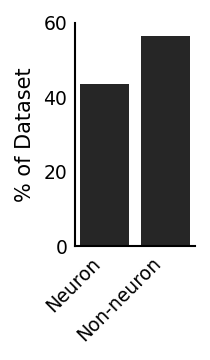

In [44]:
import matplotlib.pyplot as plt

# Count total and neuron fraction
counts = adata.obs["seurat_class"].value_counts()

neuron_count = counts.get("Neuron", 0)
total = counts.sum()
non_neuron_count = total - neuron_count

# Percentages
labels = ["Neuron", "Non-neuron"]
values = [(neuron_count / total) * 100,
          (non_neuron_count / total) * 100]

# --- Minimal plot ---
plt.figure(figsize=(1.5, 2.5), dpi=150)
plt.bar(labels, values, color=["black", "black"], alpha=0.85)   # <-- both gray

# Style: minimalist
plt.ylim(0, 60)
plt.ylabel("% of Dataset", fontsize=10)
plt.xlabel("")
plt.xticks(rotation=45, ha='right', fontsize=9)   # <-- rotated x labels
plt.yticks(fontsize=9)

# Only bottom & left spine
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1)
ax.spines['bottom'].set_linewidth(1)

# No tick marks
ax.tick_params(axis='y', length=0)
ax.tick_params(axis='x', length=0)

plt.tight_layout()
plt.show()

# Export

In [17]:
filename = os.path.join(output_dir, 'adata-merged-labels.h5ad')
os.makedirs(os.path.dirname(filename), exist_ok = True)

#adata.write_h5ad(filename, compression='gzip')

## Session info

In [18]:
print('active IDE: sc-spatial-gpu')
print('active conda environment: ', os.path.basename(sys.prefix))
session_info.show()

active IDE: sc-spatial-gpu
active conda environment:  sc-charter


/home/workspace/environment/sc-charter/lib/python3.12/site-packages/session_info/main.py:213: UserWarning: The '__version__' attribute is deprecated and will be removed in MarkupSafe 3.1. Use feature detection, or `importlib.metadata.version("markupsafe")`, instead.
  mod_version = _find_version(mod.__version__)
